#  BayesFormer for Reinforcement Learning

In [64]:
import os, sys, json
from copy import deepcopy
from datetime import datetime as dt
from ruamel.yaml import YAML
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch

from torch.nn import functional as F
dt.now()

datetime.datetime(2026, 6, 25, 17, 54, 58, 188478)

In [65]:
from TRL.common.utils import init_env,  env_reset, env_step, one_hot_encode
from TRL.networks.transition import Network as TransitionNetwork

In [66]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
display = pd.options.display
display.max_rows = 1000

In [67]:
model_details = pd.DataFrame(columns=['env','lr','context_len','hidden_dims','num_params',
                                      'data_samples','train_epochs',
                                      'avg_loss'])

In [68]:
config = "configs/config_vector-setting1.yaml"
with open(config, "r") as f:
    yaml = YAML(typ='rt')
    config = yaml.load(f)

config["experiment"]["name"] += '-transition_test'
config['gpu'] = False
config['transition']['context_length'] = 3
config['experiment']['env'] = '5'
config['transition']['heads'] = 2
config['experiment']

{'suite': 'bsuite', 'env': '5', 'test': True, 'deterministic': True, 'steps': 10000.0, 'time_limit': 300, 'test_freq': 100.0, 'name': '-transition_test', 'seed': 'None'}

In [69]:
env, possible_actions, test_env, obs_space = init_env(
    config["experiment"]["suite"], config["experiment"]["env"], test=False, 
    deterministic=config['experiment']['deterministic']
)
possible_actions = torch.tensor(possible_actions, dtype=int).reshape(len(possible_actions),-1)

_deterministic: True
deterministic True


/home/shamail/torch2_cuda12_env/lib/python3.10/site-packages/bsuite/environments/deep_sea.py:84: UserWarning: Environment is in debug mode (randomize_actions=False).Only randomized_actions=True is the DeepSea environment.
  warnings.warn('Environment is in debug mode (randomize_actions=False).'


In [70]:
config['transition']

{'training_iterations': 20, 'hidden_dim': 32, 'learning_rate': 0.01, 'window_length': 3, 'context_length': 3, 'num_encoder_layers': 2, 'heads': 2, 'forward_expansion': 4}

In [71]:
time_limit=1000
time_limit

1000

In [72]:
torch.tensor(range(config['transition']['context_length']))

tensor([0, 1, 2])

In [73]:
def generate_transition_data(config, num_transitions=100):
    env, possible_actions, test_env, obs_space = init_env(
    config["experiment"]["suite"], config["experiment"]["env"], test=False, 
    deterministic=config['experiment']['deterministic']
    )
    transitions = []
    test_transitions = {}
    state = env_reset(env, config["experiment"]["suite"])
    episodes = {
            "states": [None]*num_transitions,
            "actions": [],
            "next_states": [],
            "rewards": [],
            "terminals": [],
            "timestep": [None]*num_transitions
        }

    timestep = 0
    trajectory = np.zeros((config['transition']['context_length'], obs_space)).tolist()
    ts = np.zeros((config['transition']['context_length']),dtype=int).tolist()
    # print('init trajectory',trajectory)
    for i in range(num_transitions):
        action = env.action_space.sample()  # Random action
        next_state, reward, done = env_step(env, config['experiment']['suite'],  action)
#         print('\ntimestep:',timestep,
#               '\tstate:',state.tolist().index(1),
#               '\taction:',action,
#               '\tnext_state:',next_state.tolist().index(1) if sum(next_state) else '0',
#               '\tReward:',round(reward,4),'\tdone:',done)

#         print('\nstate:',state)
        # print('next_state',next_state)
        trajectory.append(state.tolist())
        trajectory.pop(0)
        ts.append(timestep)
        ts.pop(0)
        # print('trajectory:',trajectory)
        episodes['states'][i] = deepcopy(trajectory)
        episodes['next_states'].append(next_state.tolist())
        episodes['actions'].append(action)
        episodes['rewards'].append(reward)
        episodes['timestep'][i] = deepcopy(ts)
        episodes['terminals'].append(done)
        
        if not done:
            s = state.tolist().index(1)
            next_s_idx = next_state.tolist().index(1) if sum(next_state) else 0
            if s not in test_transitions:
                test_transitions[s] = {
                    'trajectory':deepcopy(trajectory),
                    'timestep':deepcopy(ts),
                    'next_state':[None]*len(possible_actions)
                }
                test_transitions[s]['next_state'][action] = next_s_idx
            else:
                if next_s_idx not in test_transitions[s]['next_state']:
                     test_transitions[s]['next_state'][action] = next_s_idx
        
        if done:
            state = env_reset(env, config["experiment"]["suite"])
            trajectory = np.zeros((config['transition']['context_length'], obs_space)).tolist()
            timestep = 0
            ts = np.zeros((config['transition']['context_length']),dtype=int).tolist()
        else:
            state = next_state
            timestep += 1
   
        
    return episodes, test_transitions


In [74]:
episodes, test_transitions = generate_transition_data(config, time_limit)

_deterministic: True
deterministic True


In [75]:
test_transitions.keys()

dict_keys([0, 6, 12, 5, 10, 15, 18, 16, 11, 17])

In [76]:
test_size=len(test_transitions.keys())*len(possible_actions)
test_size

20

In [77]:
s_idx = list(test_transitions.keys())
s_idx.sort()
test_transitions = {i: test_transitions[i] for i in s_idx}
test_transitions.keys()

dict_keys([0, 5, 6, 10, 11, 12, 15, 16, 17, 18])

In [78]:
test_transitions.keys()

dict_keys([0, 5, 6, 10, 11, 12, 15, 16, 17, 18])

In [79]:
len(test_transitions[0]['trajectory'][0])

25

In [80]:
print(config['transition'])
def test_model(model, test_transitions):
    iterations = 100
    obs_space = len(test_transitions[0]['trajectory'][0])
    test_state_ids = test_transitions.keys()
    true_next = deepcopy(test_transitions)
    for i in test_state_ids:
        true_next[i] = test_transitions[i]['next_state']
        
    pred = {i:{0:[],1:[]} for i in test_state_ids}
    for _ in range(iterations):
        for i in test_state_ids:
            # adding batch dimension
            observation = torch.tensor(test_transitions[i]['trajectory'],dtype=torch.float32).unsqueeze(0)
            # adding current_state as a batch for each action
            observation = torch.cat([observation for _ in possible_actions],dim=0)
            
            t = torch.tensor(test_transitions[i]['timestep'],dtype=int).unsqueeze(0)
            ts = torch.cat([t for _ in possible_actions], dim=0)   
            
            pred_next_states, pred_rewards = model.predict(ts, observation, possible_actions)            
            pred_next_states = torch.argmax(pred_next_states,1).squeeze()
#             print('\ncurrent state:',i,'\tactions:',possible_actions,'\tpred next_state:',pred_next_states,'\n')
            idx = np.argmax(observation[0].numpy(),-1)[-1]
            
            pred[idx][0].append(pred_next_states[0].item())
            pred[idx][1].append(pred_next_states[1].item())
            
            t = torch.tensor(range(1,config['transition']['context_length']+1),dtype=int)
    
    data = []
    for i,state_idx in enumerate(test_state_ids):    
        for a in possible_actions:
            result = {}
            result['current_state'] = state_idx
            result['action'] = a.item()
            next_state = true_next[state_idx][a.item()] if true_next[state_idx][a.item()] else obs_space-1
            result['true next_state'] = next_state
            
            result['pred next_state'] = np.round(np.mean(pred[state_idx][a.item()],0))
            result['variance'] = np.round(np.var(pred[state_idx][a.item()],0),4)
            data.append(result)
    data = pd.DataFrame(data)

    return data



{'training_iterations': 20, 'hidden_dim': 32, 'learning_rate': 0.01, 'window_length': 3, 'context_length': 3, 'num_encoder_layers': 2, 'heads': 2, 'forward_expansion': 4}


In [81]:
states = torch.tensor(episodes['states'])
next_states = torch.tensor(episodes['next_states'])
timesteps = torch.tensor(episodes['timestep'], dtype=int)
rewards = torch.tensor(episodes['rewards']).unsqueeze(1)
actions = torch.tensor(episodes['actions'], dtype=int).unsqueeze(1)

In [82]:
timesteps.shape, timesteps[:3]

(torch.Size([1000, 3]),
 tensor([[0, 0, 0],
         [0, 0, 1],
         [0, 1, 2]]))

In [83]:
states.shape, states[:3]

(torch.Size([1000, 3, 25]),
 tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0.],
          [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0.]],
 
         [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0.],
          [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0.]],
 
         [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0.,

In [84]:
learning_rate = 1e-3
num_epochs = 100
config["transition"]

{'training_iterations': 20, 'hidden_dim': 32, 'learning_rate': 0.01, 'window_length': 3, 'context_length': 3, 'num_encoder_layers': 2, 'heads': 2, 'forward_expansion': 4}

In [85]:
# learning_rate = 1e-3
config["transition"]["hidden_dim"] = 8
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run2 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run2.append(loss.item())

print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))

performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 2674
Correct preds: 0 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,9.0,1.6824
1,0,1,6,9.0,0.9075
2,5,0,10,9.0,0.2944
3,5,1,11,10.0,3.8275
4,6,0,10,9.0,1.6516
5,6,1,12,9.0,1.8756
6,10,0,15,9.0,1.6200
7,10,1,16,9.0,0.9739
8,11,0,15,9.0,3.0504
9,11,1,17,10.0,4.5600


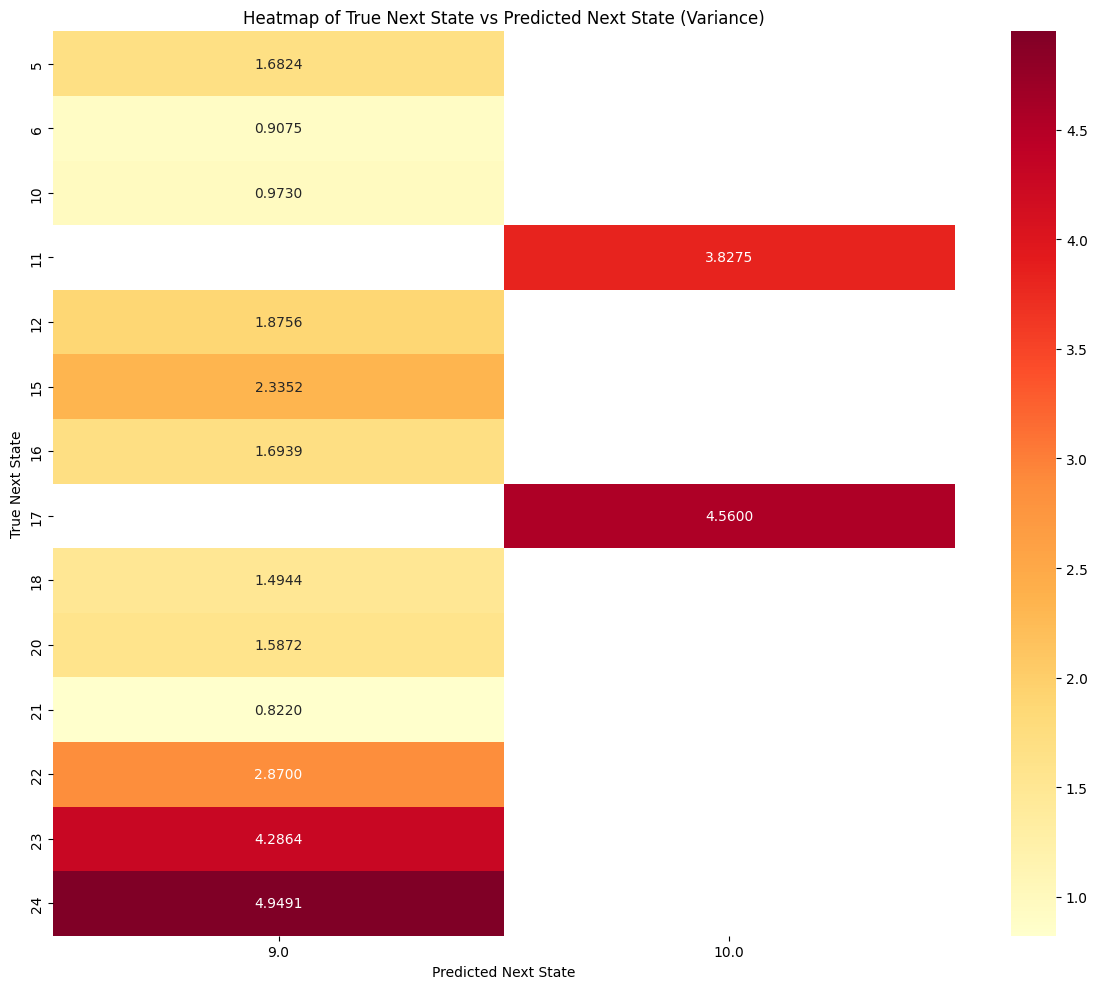

In [86]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [87]:
# learning_rate = 1e-3
config["transition"]["hidden_dim"] = 16
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run3 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run3.append(loss.item())

print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))

performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 9354
Correct preds: 0 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,10.0,6.4371
1,0,1,6,9.0,10.8051
2,5,0,10,11.0,6.3196
3,5,1,11,10.0,11.4136
4,6,0,10,11.0,5.3236
5,6,1,12,11.0,11.2699
6,10,0,15,12.0,7.0179
7,10,1,16,11.0,16.8819
8,11,0,15,12.0,11.1176
9,11,1,17,10.0,17.0756


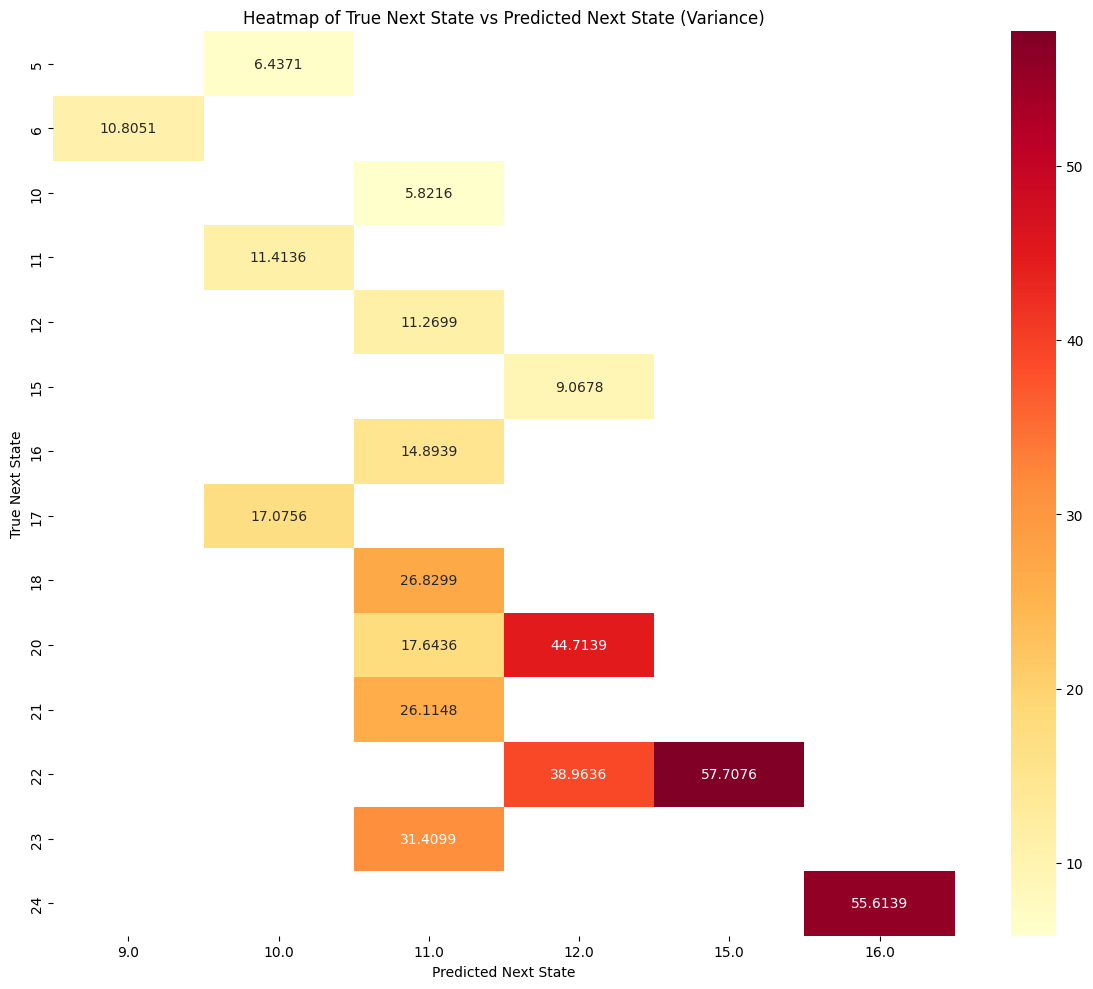

In [88]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [89]:
# learning_rate = 1e-3
config["transition"]["hidden_dim"] = 32
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run4 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run4.append(loss.item())

print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))

performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 34810
Correct preds: 6 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,6.0,17.6475
1,0,1,6,6.0,0.8344
2,5,0,10,10.0,34.3979
3,5,1,11,9.0,7.1571
4,6,0,10,8.0,23.9475
5,6,1,12,9.0,9.6411
6,10,0,15,15.0,0.8019
7,10,1,16,14.0,5.9379
8,11,0,15,15.0,0.9900
9,11,1,17,14.0,6.0939


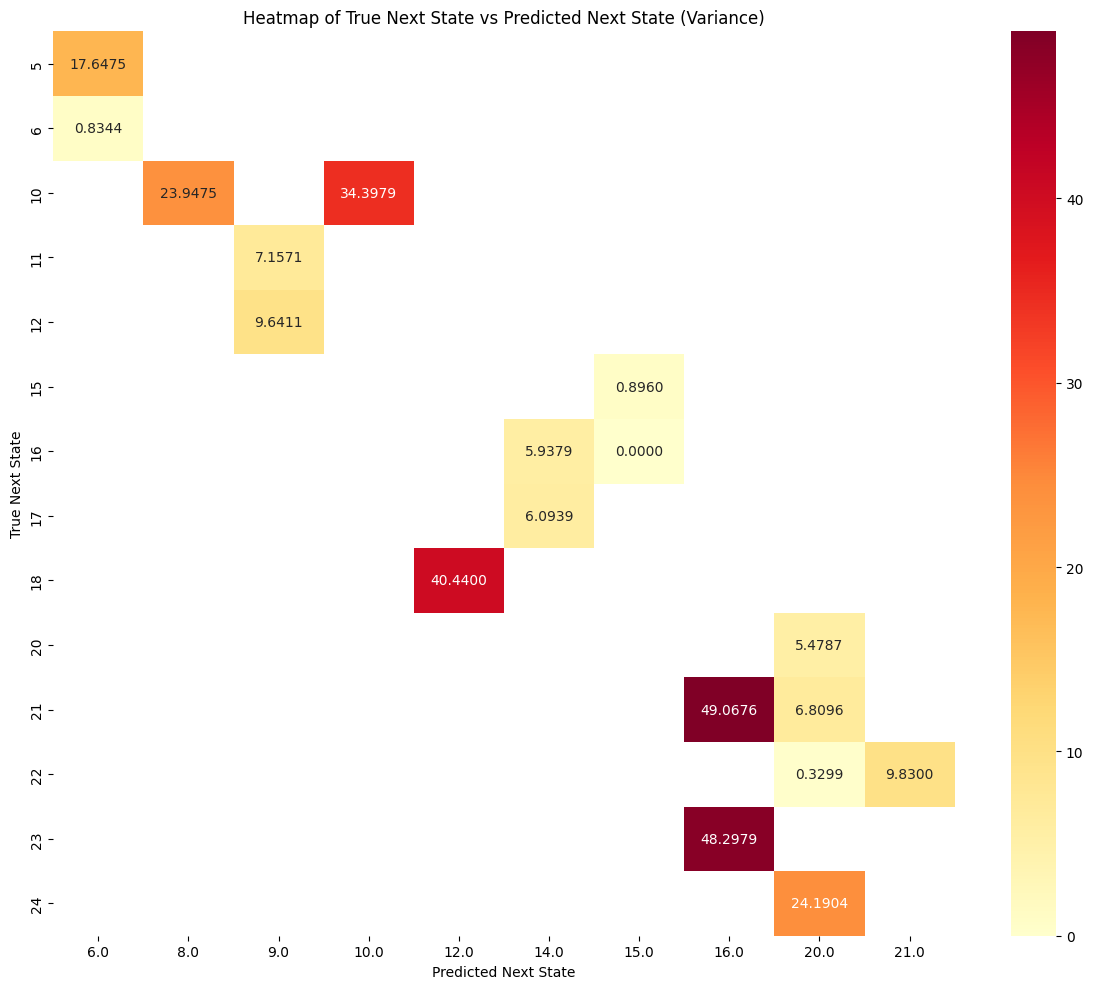

In [90]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [91]:
print(f"\nAvg Train Loss: {sum(total_loss_run4) / num_epochs}")
print('Final state_loss:',state_loss.item(),'\treward_loss:',reward_loss.item())
actual_next_s_idx = torch.argmax(next_states,1).squeeze()
predicted_next_s_idx = torch.argmax(predicted_next_states,1)
print('STATE RMSE',(torch.sum(
    (actual_next_s_idx-predicted_next_s_idx)**2)/len(next_states)
)**0.5)

data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run4)
}])
model_details = pd.concat([model_details,data], ignore_index=True)
# model_details


Avg Train Loss: 0.04607377612963319
Final state_loss: 0.025465352460741997 	reward_loss: 0.0015674075111746788
STATE RMSE tensor(6.4841)


/tmp/ipykernel_153593/1722788380.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_details = pd.concat([model_details,data], ignore_index=True)


In [92]:
# learning_rate = 1e-3
config["transition"]["hidden_dim"] = 64
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run5 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run5.append(loss.item())

print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))

performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 134106
Correct preds: 14 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,0.0000
1,0,1,6,6.0,0.0000
2,5,0,10,10.0,0.0000
3,5,1,11,11.0,0.2584
4,6,0,10,10.0,0.0000
5,6,1,12,12.0,0.0196
6,10,0,15,15.0,0.0000
7,10,1,16,16.0,0.0396
8,11,0,15,15.0,0.0000
9,11,1,17,16.0,1.9939


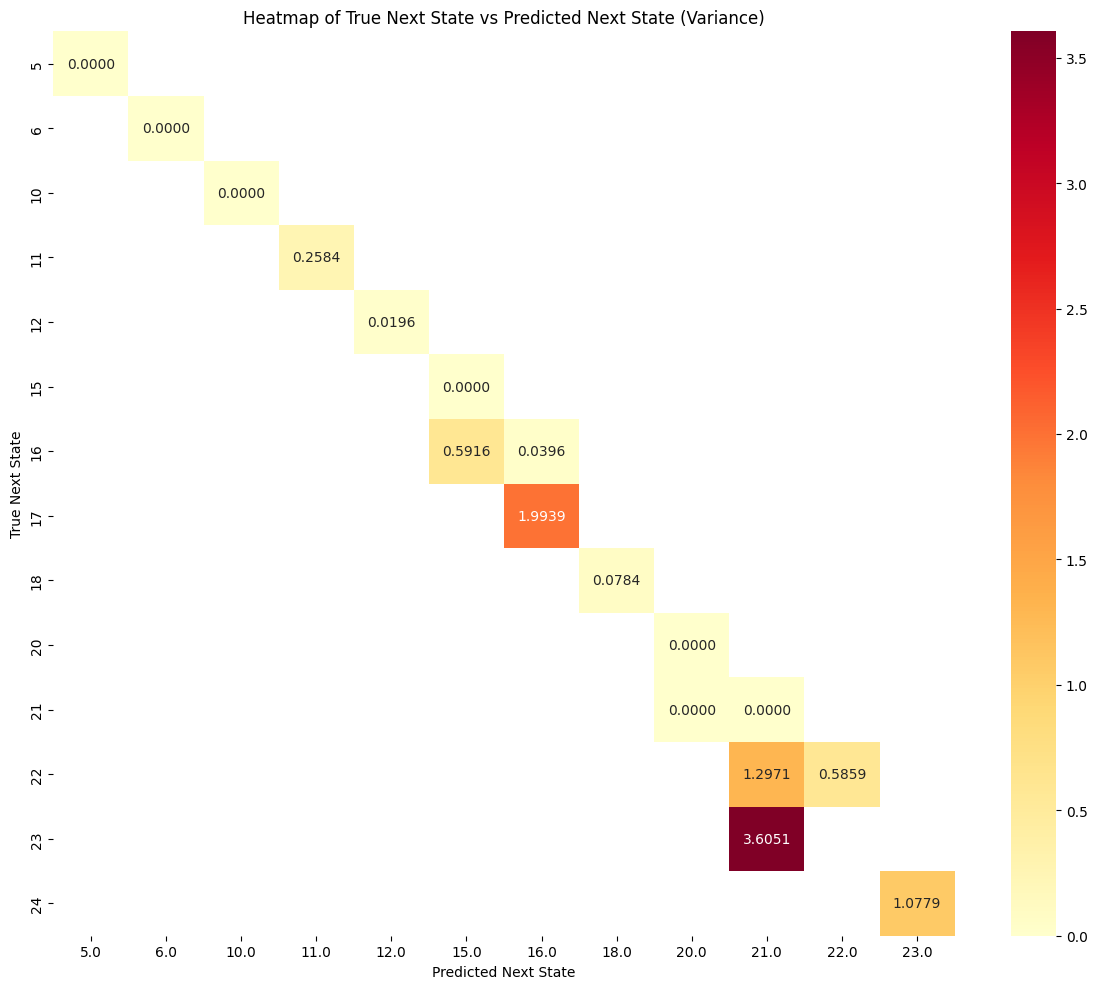

In [93]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [94]:
print(f"\nAvg Train Loss: {sum(total_loss_run5) / num_epochs}")
print('Final state_loss:',state_loss.item(),'\treward_loss:',reward_loss.item())
actual_next_s_idx = torch.argmax(next_states,1).squeeze()
predicted_next_s_idx = torch.argmax(predicted_next_states,1)
print('STATE RMSE',(torch.sum(
    (actual_next_s_idx-predicted_next_s_idx)**2)/len(next_states)
)**0.5)

data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run5)
}])
model_details = pd.concat([model_details,data], ignore_index=True)
# model_details


Avg Train Loss: 0.03483650063164532
Final state_loss: 0.010790348052978516 	reward_loss: 0.0012225433019921184
STATE RMSE tensor(6.5973)


In [95]:
learning_rate = 1e-3
config["transition"]["hidden_dim"] = 128
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run6 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run6.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))

performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 526234
Correct preds: 18 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,0.0000
1,0,1,6,6.0,0.0000
2,5,0,10,10.0,0.0000
3,5,1,11,11.0,0.0000
4,6,0,10,10.0,0.0000
5,6,1,12,12.0,0.0000
6,10,0,15,15.0,0.0000
7,10,1,16,16.0,0.0000
8,11,0,15,15.0,0.0000
9,11,1,17,17.0,0.7684


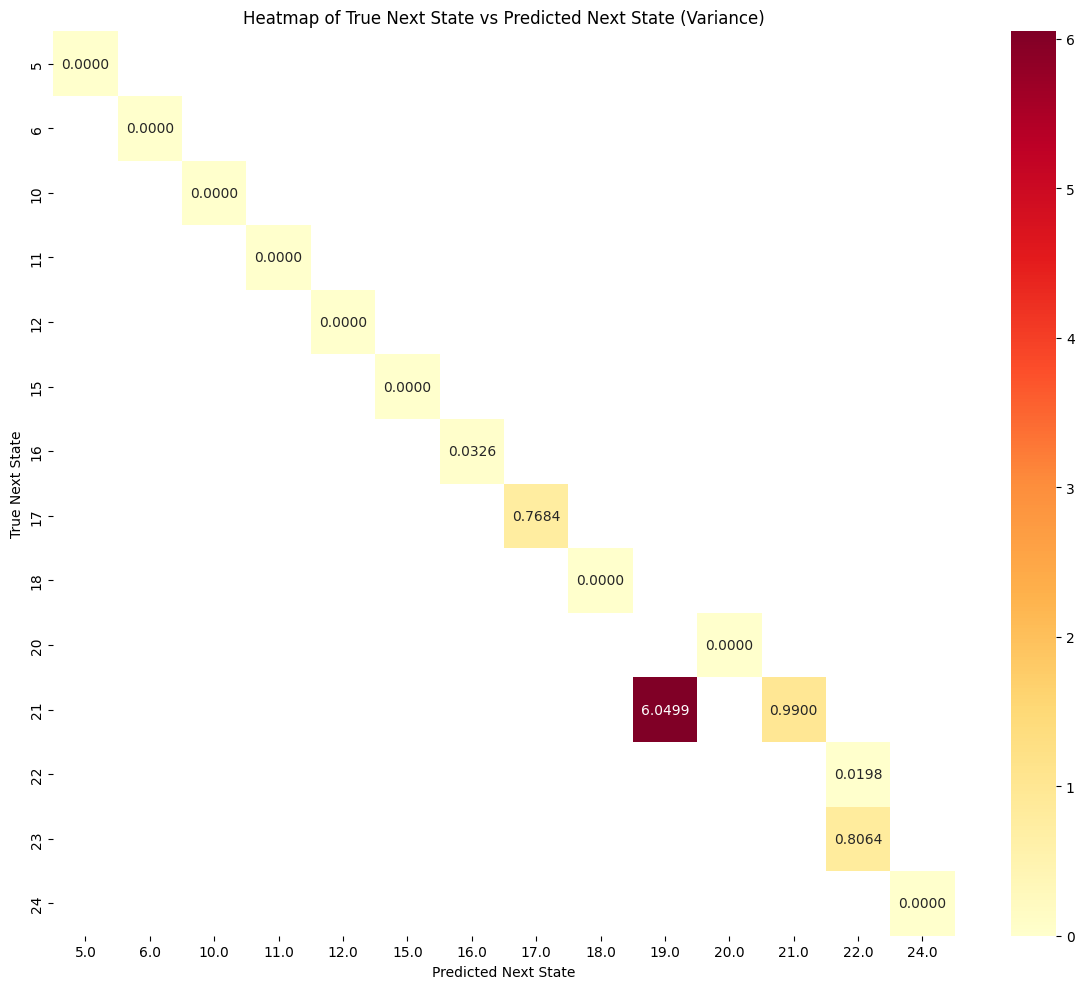

In [96]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [97]:
print(f"\nAvg Train Loss: {sum(total_loss_run6) / num_epochs}")
print('Final state_loss:',state_loss.item(),'\treward_loss:',reward_loss.item())
actual_next_s_idx = torch.argmax(next_states,1).squeeze()
predicted_next_s_idx = torch.argmax(predicted_next_states,1)
print('STATE RMSE',(torch.sum(
    (actual_next_s_idx-predicted_next_s_idx)**2)/len(next_states)
)**0.5)

data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run6)
}])
model_details = pd.concat([model_details,data], ignore_index=True)
model_details


Avg Train Loss: 0.04530546993948519
Final state_loss: 0.007484082598239183 	reward_loss: 0.0007496132748201489
STATE RMSE tensor(6.2335)


,env,lr,context_len,hidden_dims,num_params,data_samples,train_epochs,avg_loss,best_loss
0,5,0.001,3,32,34810,1000,100,NaN,0.027033
1,5,0.001,3,64,134106,1000,100,NaN,0.012013
2,5,0.001,3,128,526234,1000,100,NaN,0.008234


In [98]:
learning_rate = 1e-3
config["transition"]["hidden_dim"] = 256
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run7 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run7.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))

performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 2084634
Correct preds: 16 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,0.0000
1,0,1,6,6.0,0.0000
2,5,0,10,10.0,0.0000
3,5,1,11,11.0,0.0000
4,6,0,10,10.0,0.0000
5,6,1,12,12.0,0.0000
6,10,0,15,15.0,0.0000
7,10,1,16,16.0,0.0000
8,11,0,15,15.0,0.0000
9,11,1,17,17.0,0.0291


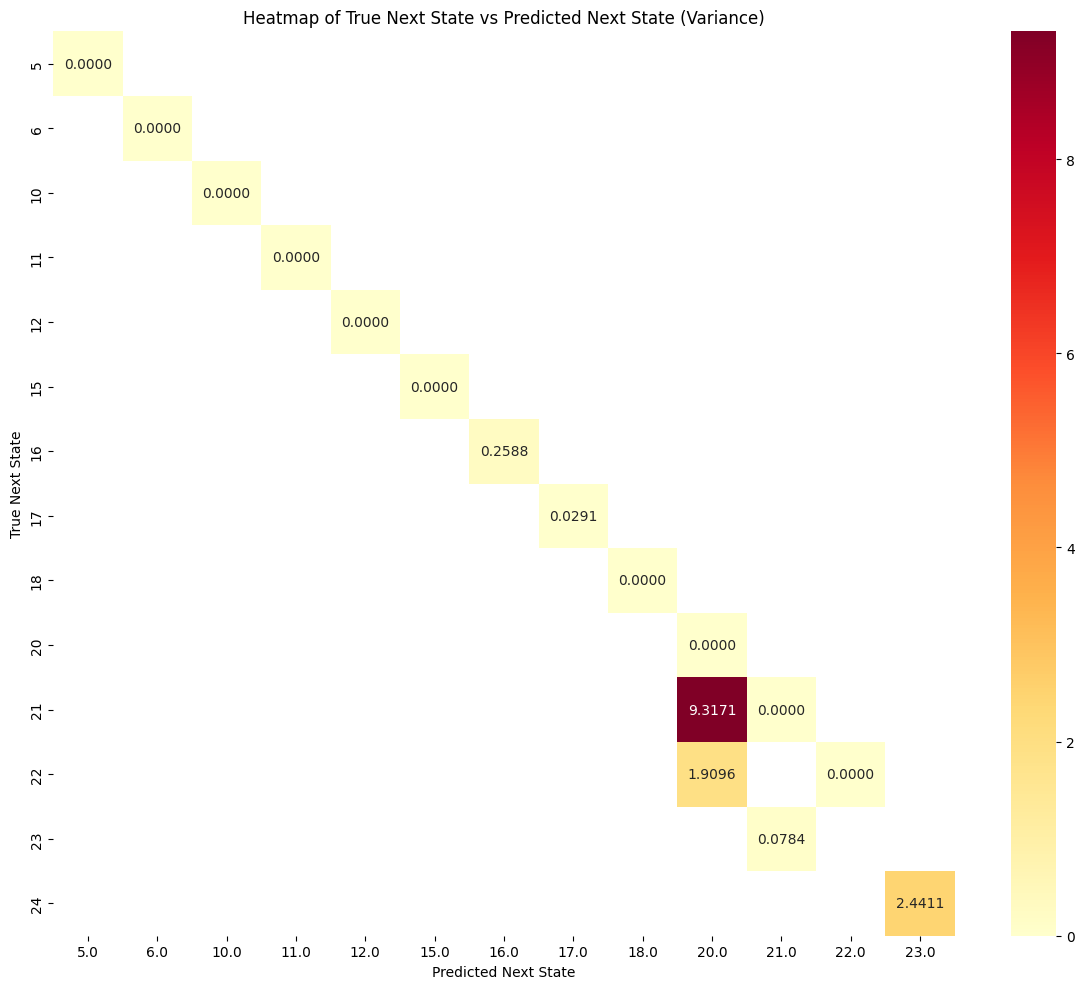

In [99]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [100]:
learning_rate = 1e-3
config["transition"]["hidden_dim"] = 512
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run8 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run8.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))

performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 8298010
Correct preds: 4 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,0.0000
1,0,1,6,6.0,0.0000
2,5,0,10,6.0,7.3600
3,5,1,11,6.0,0.9600
4,6,0,10,7.0,11.8475
5,6,1,12,6.0,0.0000
6,10,0,15,15.0,0.0000
7,10,1,16,8.0,14.9875
8,11,0,15,15.0,0.0000
9,11,1,17,7.0,9.8596


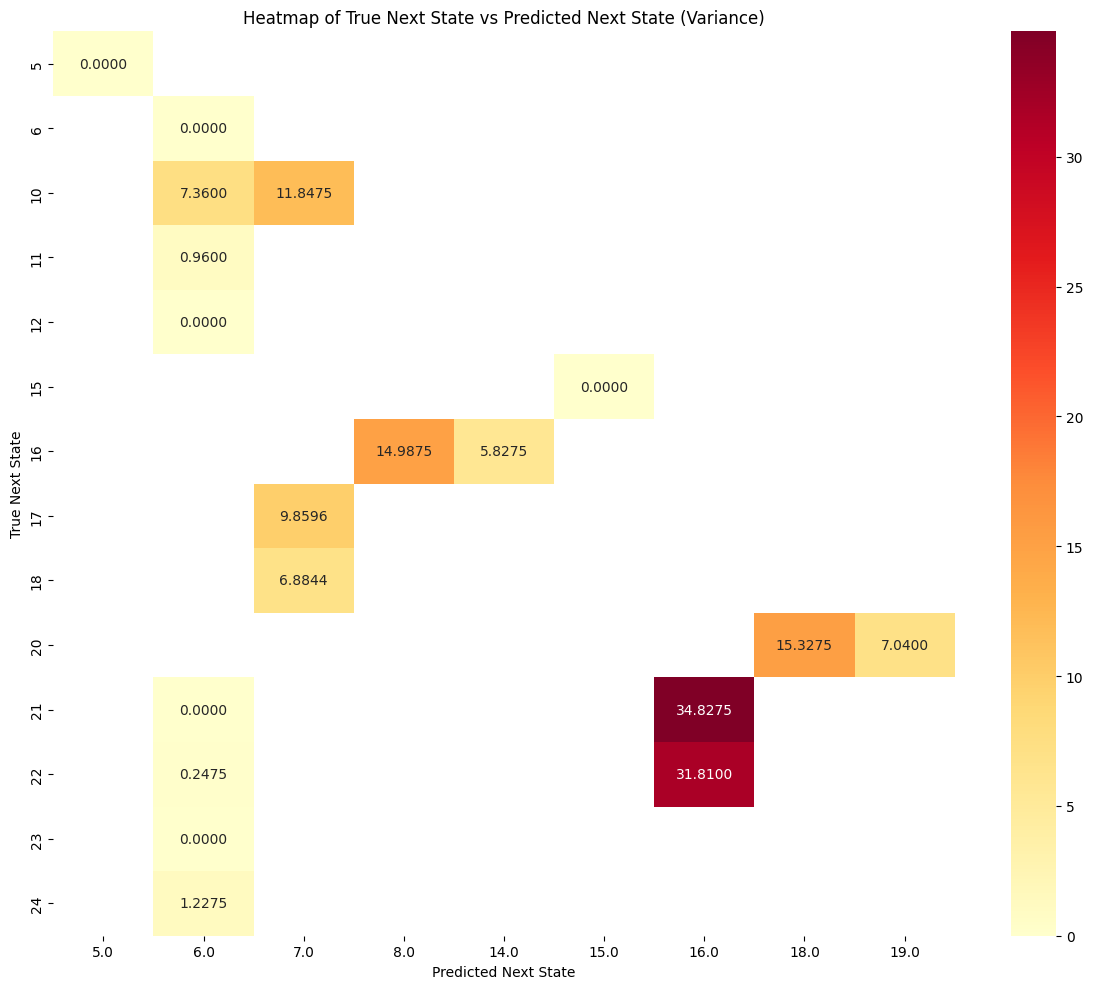

In [101]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

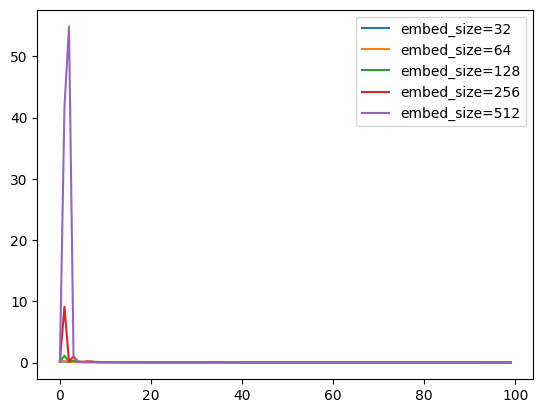

In [102]:

plt.plot(range(num_epochs), total_loss_run4, label='embed_size=32')
plt.plot(range(num_epochs), total_loss_run5, label='embed_size=64')
plt.plot(range(num_epochs), total_loss_run6, label='embed_size=128')
plt.plot(range(num_epochs), total_loss_run7, label='embed_size=256')
plt.plot(range(num_epochs), total_loss_run8, label='embed_size=512')
plt.legend()
# learning_rate = 1e-3

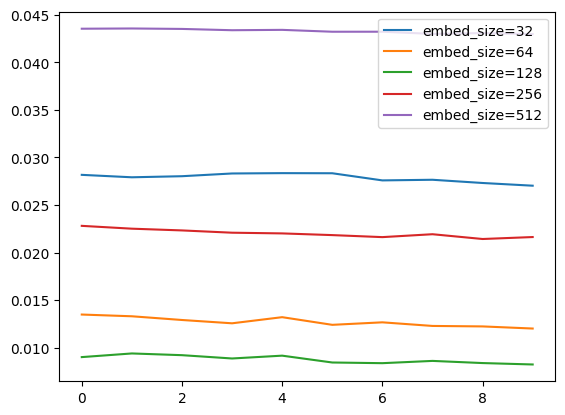

In [103]:
# zooming into the last 10 epochs
plt.plot(range(10), total_loss_run4[-10:], label='embed_size=32')
plt.plot(range(10), total_loss_run5[-10:], label='embed_size=64')
plt.plot(range(10), total_loss_run6[-10:], label='embed_size=128')
plt.plot(range(10), total_loss_run7[-10:], label='embed_size=256')
plt.plot(range(10), total_loss_run8[-10:], label='embed_size=512')
plt.legend()

In [104]:
learning_rate = 1e-4

In [105]:
# lr: 1e-4
config["transition"]["hidden_dim"] = 32
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run4 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run4.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))
performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 34810
Correct preds: 3 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,13.0,47.6396
1,0,1,6,16.0,28.9736
2,5,0,10,13.0,54.6539
3,5,1,11,16.0,37.5475
4,6,0,10,13.0,58.2896
5,6,1,12,16.0,39.8699
6,10,0,15,13.0,46.8024
7,10,1,16,16.0,25.0104
8,11,0,15,15.0,54.1075
9,11,1,17,17.0,25.9644


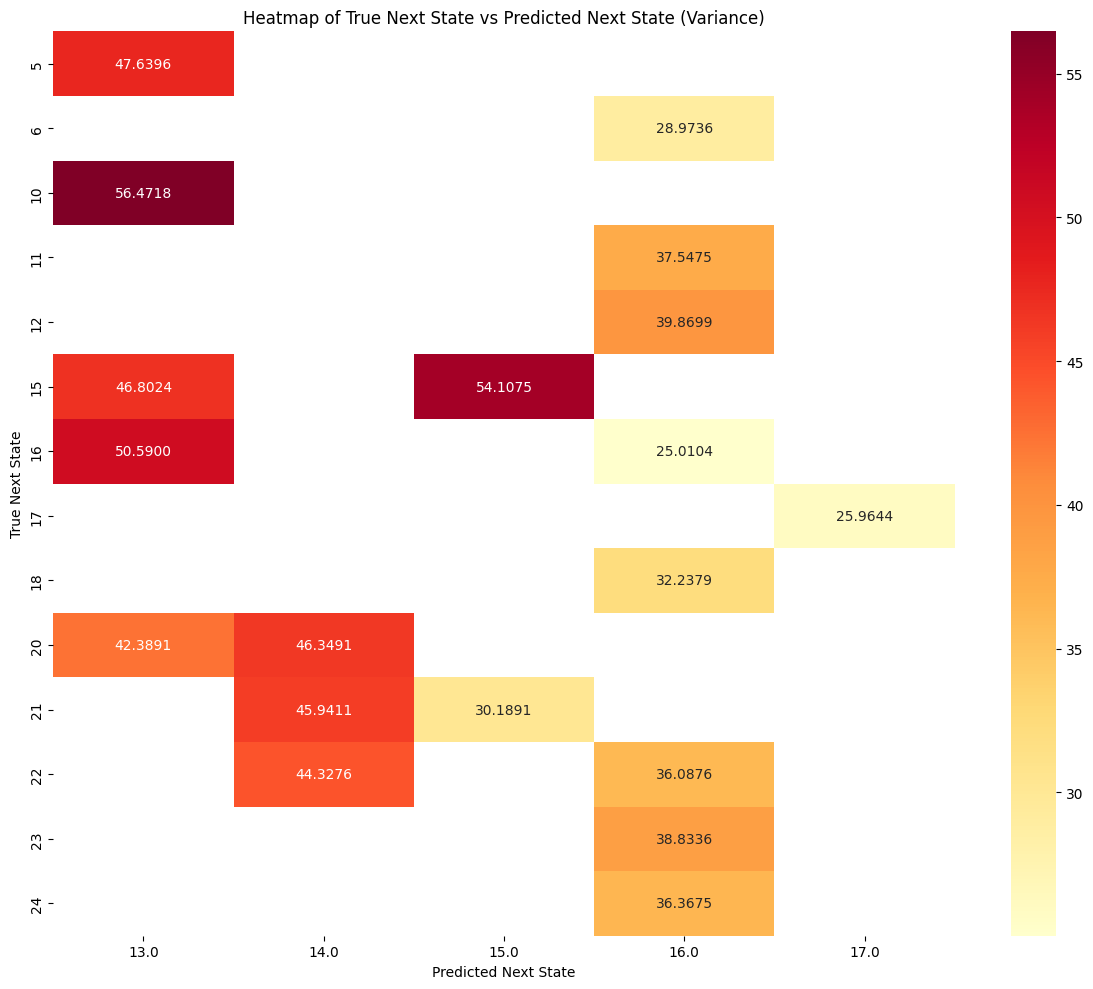

In [106]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [107]:
print(f"\nAvg Train Loss: {sum(total_loss_run4) / num_epochs}")
print('Final state_loss:',state_loss.item(),'\treward_loss:',reward_loss.item())
actual_next_s_idx = torch.argmax(next_states,1).squeeze()
predicted_next_s_idx = torch.argmax(predicted_next_states,1)
print('STATE RMSE',(torch.sum(
    (actual_next_s_idx-predicted_next_s_idx)**2)/len(next_states)
)**0.5)

data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run4)
}])
model_details = pd.concat([model_details,data], ignore_index=True)
# model_details


Avg Train Loss: 0.10059809796512127
Final state_loss: 0.04418125003576279 	reward_loss: 0.022854335606098175
STATE RMSE tensor(10.3723)


In [108]:
# lr: 1e-4
config["transition"]["hidden_dim"] = 64
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run5 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run5.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))
performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 134106
Correct preds: 0 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,10.0,37.1811
1,0,1,6,10.0,42.0099
2,5,0,10,11.0,34.0411
3,5,1,11,14.0,39.5004
4,6,0,10,13.0,36.1776
5,6,1,12,16.0,34.5296
6,10,0,15,14.0,18.2211
7,10,1,16,15.0,19.7771
8,11,0,15,14.0,21.4811
9,11,1,17,15.0,20.1291


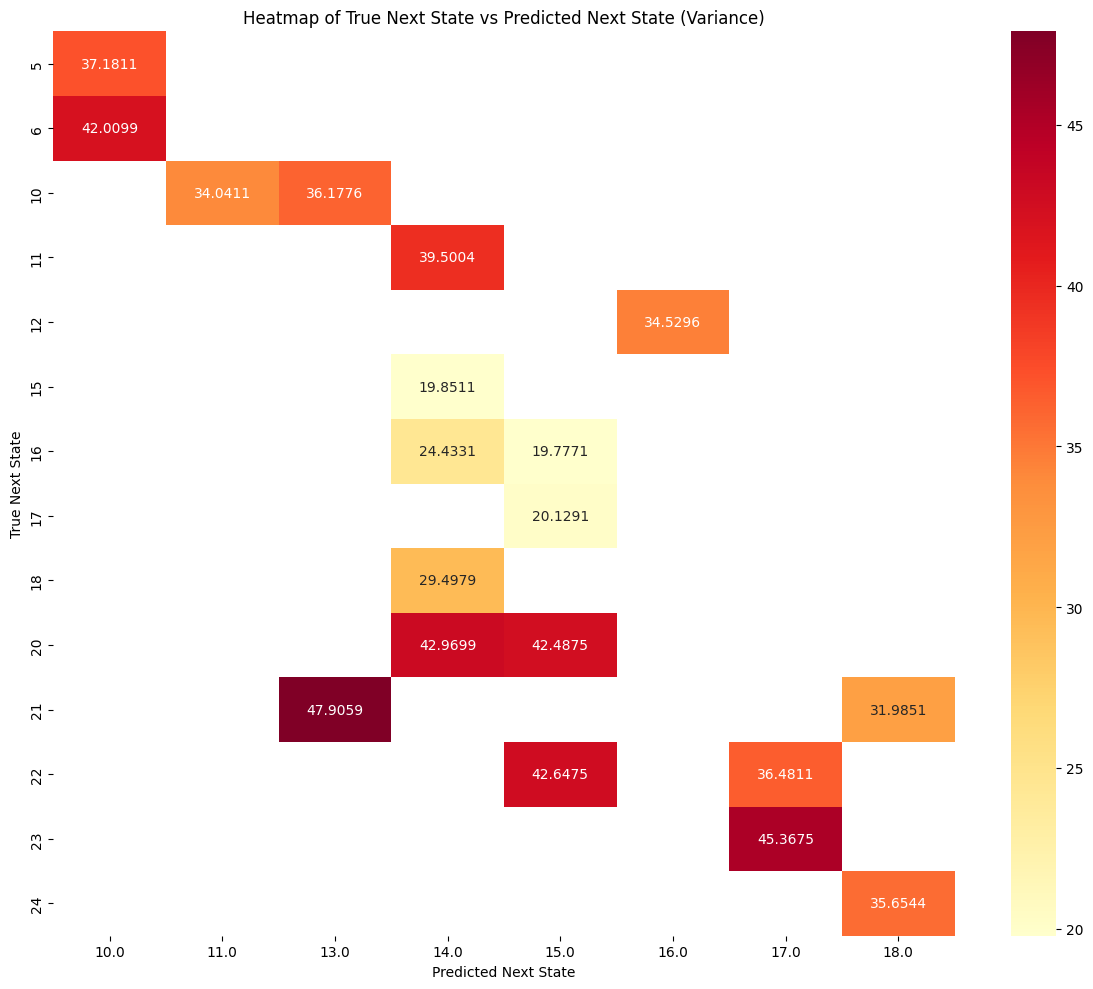

In [109]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [110]:
print(f"\nAvg Train Loss: {sum(total_loss_run5) / num_epochs}")
print('Final state_loss:',state_loss.item(),'\treward_loss:',reward_loss.item())
actual_next_s_idx = torch.argmax(next_states,1).squeeze()
predicted_next_s_idx = torch.argmax(predicted_next_states,1)
print('STATE RMSE',(torch.sum(
    (actual_next_s_idx-predicted_next_s_idx)**2)/len(next_states)
)**0.5)

data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run5)
}])
model_details = pd.concat([model_details,data], ignore_index=True)
# model_details


Avg Train Loss: 0.06673103768378497
Final state_loss: 0.031477998942136765 	reward_loss: 0.013390677981078625
STATE RMSE tensor(9.0971)


In [111]:
# lr: 1e-4
config["transition"]["hidden_dim"] = 128
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run6 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run6.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))
performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 526234
Correct preds: 3 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,0.7344
1,0,1,6,6.0,0.2584
2,5,0,10,8.0,10.1100
3,5,1,11,10.0,25.3516
4,6,0,10,8.0,10.7579
5,6,1,12,11.0,8.6436
6,10,0,15,14.0,7.2379
7,10,1,16,16.0,14.0064
8,11,0,15,14.0,10.4339
9,11,1,17,15.0,26.9124


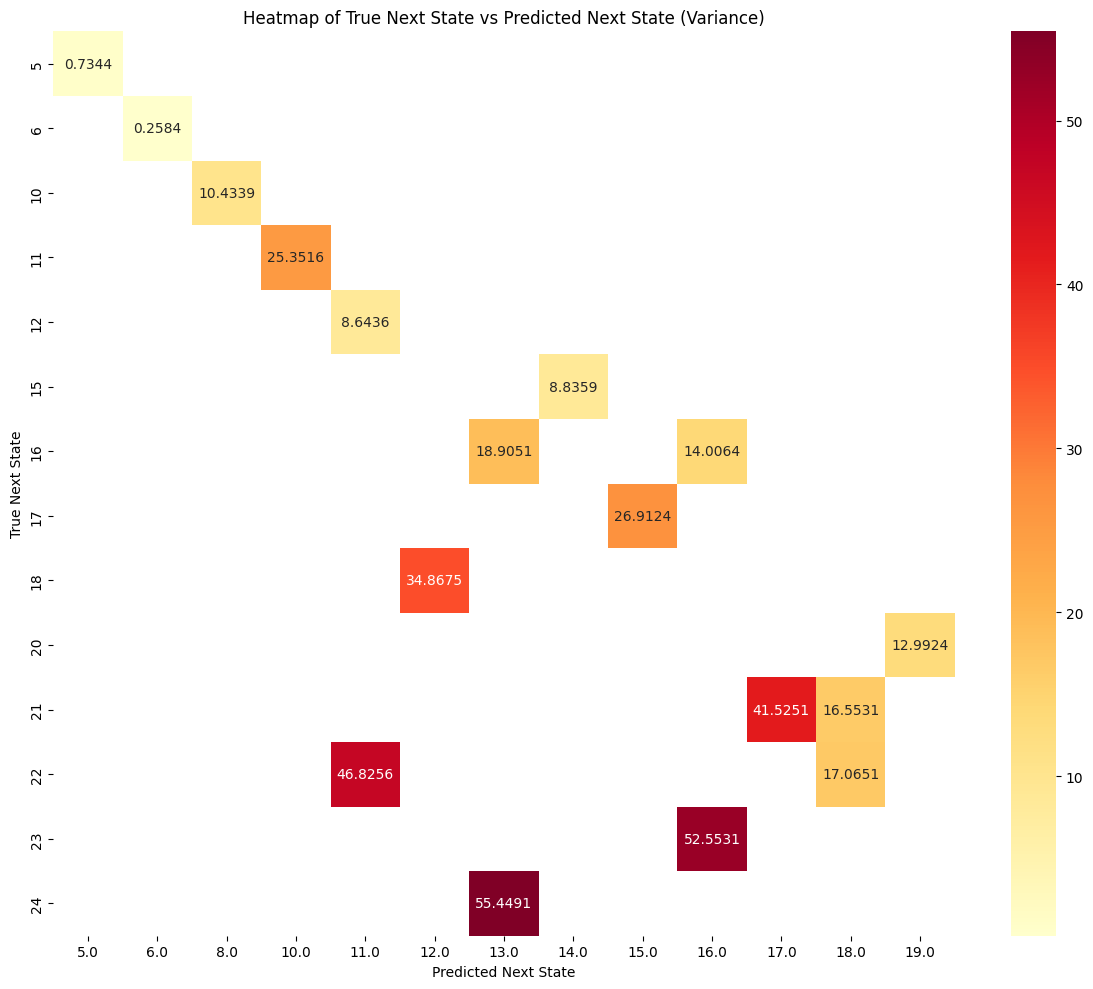

In [112]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [113]:
print(f"\nAvg Train Loss: {sum(total_loss_run6) / num_epochs}")
print('Final state_loss:',state_loss.item(),'\treward_loss:',reward_loss.item())
actual_next_s_idx = torch.argmax(next_states,1).squeeze()
predicted_next_s_idx = torch.argmax(predicted_next_states,1)
print('STATE RMSE',(torch.sum(
    (actual_next_s_idx-predicted_next_s_idx)**2)/len(next_states)
)**0.5)

data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run6)
}])
model_details = pd.concat([model_details,data], ignore_index=True)
model_details


Avg Train Loss: 0.05745666146278381
Final state_loss: 0.026065178215503693 	reward_loss: 0.00950950663536787
STATE RMSE tensor(8.3604)


,env,lr,context_len,hidden_dims,num_params,data_samples,train_epochs,avg_loss,best_loss
0,5,0.0010,3,32,34810,1000,100,NaN,0.027033
1,5,0.0010,3,64,134106,1000,100,NaN,0.012013
2,5,0.0010,3,128,526234,1000,100,NaN,0.008234
3,5,0.0001,3,32,34810,1000,100,NaN,0.067036
4,5,0.0001,3,64,134106,1000,100,NaN,0.044869
5,5,0.0001,3,128,526234,1000,100,NaN,0.035575


In [114]:
# lr: 1e-4
config["transition"]["hidden_dim"] = 256
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run7 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run7.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))
performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 2084634
Correct preds: 15 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,0.0000
1,0,1,6,6.0,0.0000
2,5,0,10,10.0,0.0000
3,5,1,11,11.0,0.0000
4,6,0,10,10.0,0.0000
5,6,1,12,12.0,0.7600
6,10,0,15,15.0,0.0000
7,10,1,16,16.0,2.3336
8,11,0,15,15.0,0.0000
9,11,1,17,17.0,3.3219


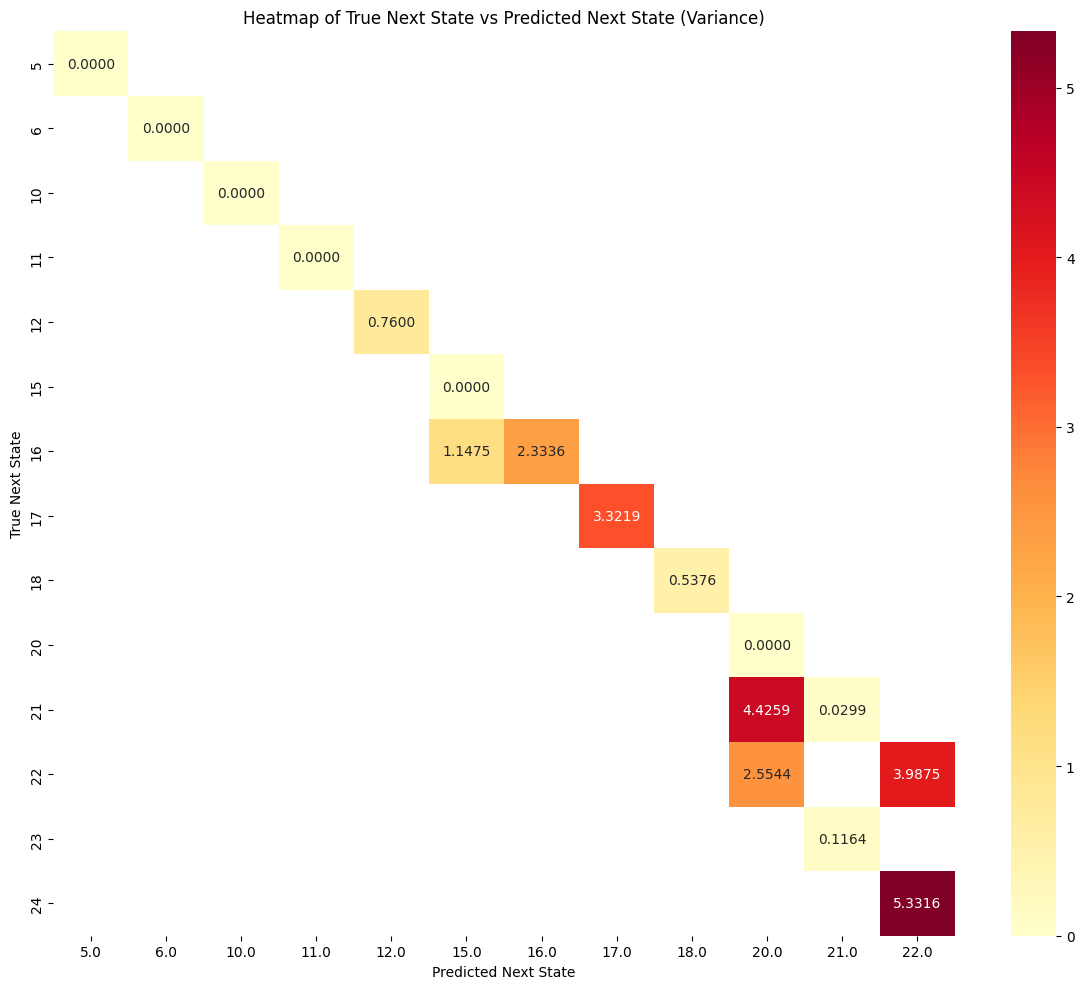

In [115]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [116]:
data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run7)
}])
model_details = pd.concat([model_details,data], ignore_index=True)


In [117]:
learning_rate = 1e-4
config["transition"]["hidden_dim"] = 512
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run8 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run8.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))
performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 8298010
Correct preds: 19 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,0.0000
1,0,1,6,6.0,0.0000
2,5,0,10,10.0,0.0000
3,5,1,11,11.0,0.0000
4,6,0,10,10.0,0.0000
5,6,1,12,12.0,0.0000
6,10,0,15,15.0,0.0000
7,10,1,16,16.0,0.0000
8,11,0,15,15.0,0.0000
9,11,1,17,17.0,0.0000


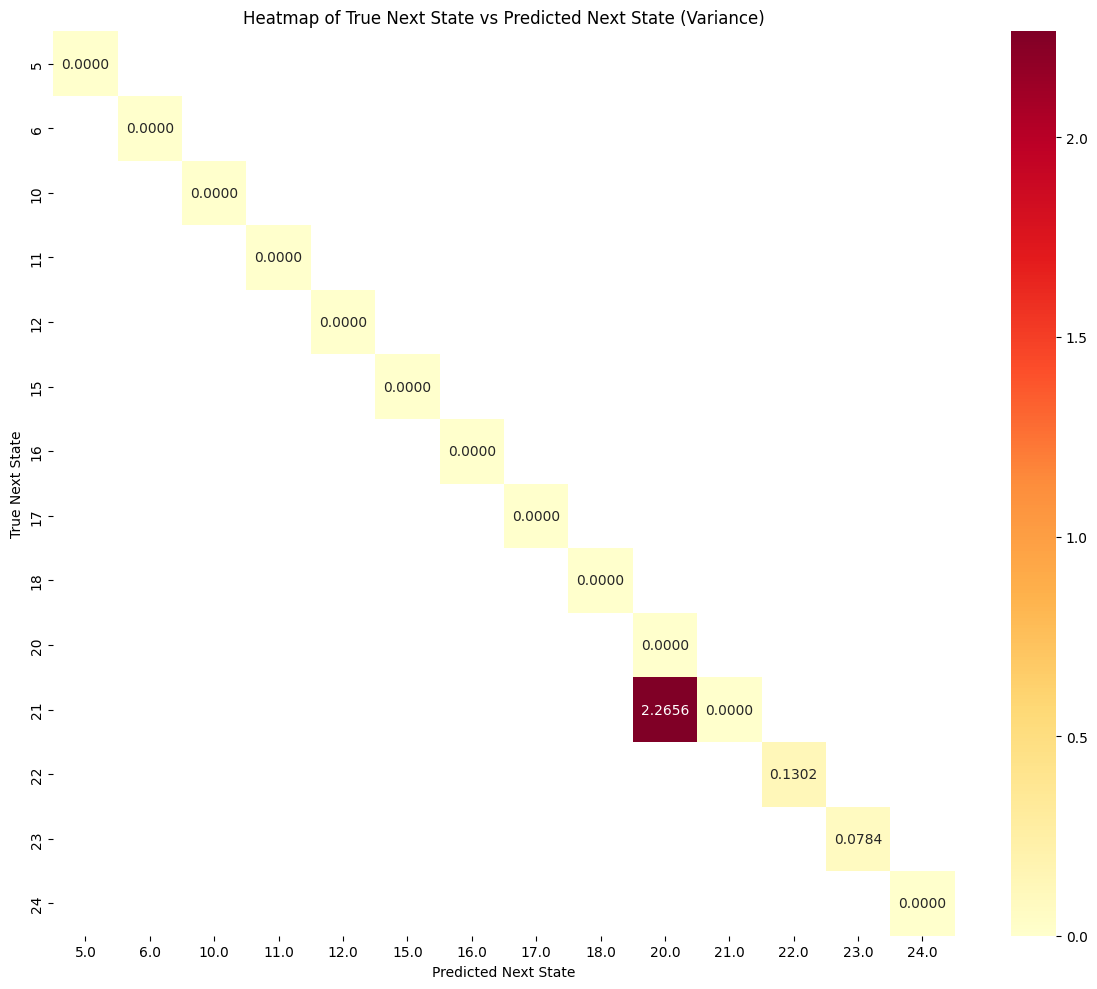

In [118]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [119]:
data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run8)
}])
model_details = pd.concat([model_details,data], ignore_index=True)


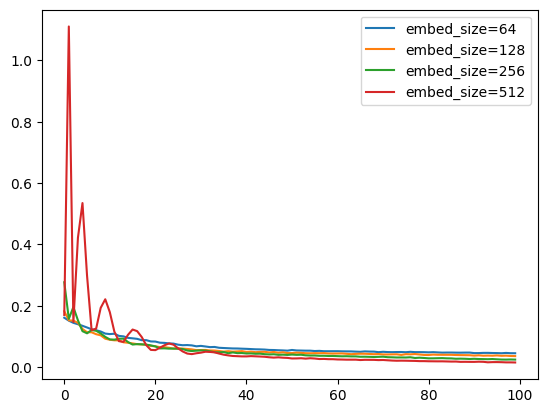

In [120]:

plt.plot(range(num_epochs), total_loss_run5, label='embed_size=64')
plt.plot(range(num_epochs), total_loss_run6, label='embed_size=128')
plt.plot(range(num_epochs), total_loss_run7, label='embed_size=256')
plt.plot(range(num_epochs), total_loss_run8, label='embed_size=512')
plt.legend()
# learning_rate = 1e-4

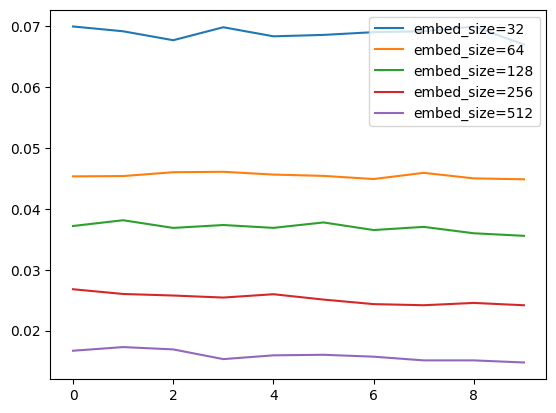

In [121]:
# zooming into the last 10 epochs
plt.plot(range(10), total_loss_run4[-10:], label='embed_size=32')
plt.plot(range(10), total_loss_run5[-10:], label='embed_size=64')
plt.plot(range(10), total_loss_run6[-10:], label='embed_size=128')
plt.plot(range(10), total_loss_run7[-10:], label='embed_size=256')
plt.plot(range(10), total_loss_run8[-10:], label='embed_size=512')
plt.legend()

In [122]:
model_details

,env,lr,context_len,hidden_dims,num_params,data_samples,train_epochs,avg_loss,best_loss
0,5,0.0010,3,32,34810,1000,100,NaN,0.027033
1,5,0.0010,3,64,134106,1000,100,NaN,0.012013
2,5,0.0010,3,128,526234,1000,100,NaN,0.008234
3,5,0.0001,3,32,34810,1000,100,NaN,0.067036
4,5,0.0001,3,64,134106,1000,100,NaN,0.044869
5,5,0.0001,3,128,526234,1000,100,NaN,0.035575
6,5,0.0001,3,256,2084634,1000,100,NaN,0.024160
7,5,0.0001,3,512,8298010,1000,100,NaN,0.014752


In [123]:
# model_details.to_csv('transition_model_experiments.csv',header=False,mode='a')

## Locked vs Unlocked Variance Demonstration

**What this shows:** `EpisodeLockedDropout` is the fix for the Dithering Trap (Problem #1) and Representation Drift (Problem #2).

- **Unlocked (stochastic)**: Each of the 100 `predict()` calls draws a fresh random dropout mask. The same (state, action) pair produces different next-state predictions every call ﷿﷿﷿﷿﷿﷿﷿﷿﷿ non-zero variance. This is the *broken* BayesFormer behaviour ﷿﷿﷿﷿﷿﷿﷿﷿﷿ the agent's imagined world changes every step, so it cannot commit to a consistent exploration strategy.

- **Locked (episode-consistent)**: `lock_all_dropouts()` samples one mask set once and freezes it. All 100 `predict()` calls use the **identical** mask ﷿﷿﷿﷿﷿﷿﷿﷿﷿ identical predictions ﷿﷿﷿﷿﷿﷿﷿﷿﷿ **variance = 0.0 exactly**. This is Thompson Sampling working correctly: one sampled world hypothesis M﷿﷿﷿﷿﷿﷿ held fixed for the entire episode.

The locked model gets the same *correct predictions* as the unlocked model ﷿﷿﷿﷿﷿﷿﷿﷿﷿ locking does not hurt accuracy, it only removes the harmful stochasticity.

In [124]:
# === UNLOCKED: stochastic masks ﷿﷿﷿﷿﷿﷿﷿﷿﷿ a different mask drawn every predict() call ===
# transition_network is the best model from above: hidden_dim=512, lr=1e-4, 19/20 correct
result_unlocked = test_model(transition_network, test_transitions)

print("=== UNLOCKED (stochastic masks ﷿﷿﷿﷿﷿﷿﷿﷿﷿ original broken behaviour) ===")
print("Correct preds:", sum(result_unlocked['true next_state'] == result_unlocked['pred next_state']), '/', test_size)
print("Mean variance: %.4f" % result_unlocked['variance'].mean())
print("Max  variance: %.4f" % result_unlocked['variance'].max())
result_unlocked[['current_state', 'action', 'true next_state', 'pred next_state', 'variance']]

=== UNLOCKED (stochastic masks ﷿﷿﷿﷿﷿﷿﷿﷿﷿ original broken behaviour) ===
Correct preds: 19 / 20
Mean variance: 0.1364
Max  variance: 2.2531


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,0.0000
1,0,1,6,6.0,0.0000
2,5,0,10,10.0,0.0000
3,5,1,11,11.0,0.0000
4,6,0,10,10.0,0.0000
5,6,1,12,12.0,0.0000
6,10,0,15,15.0,0.0000
7,10,1,16,16.0,0.0099
8,11,0,15,15.0,0.0000
9,11,1,17,17.0,0.0000


In [125]:
# === LOCKED: one fixed mask sampled once ﷿﷿﷿﷿﷿﷿﷿﷿﷿ every predict() call uses the same mask ===
N_actions  = len(possible_actions)
context_len = config['transition']['context_length']

transition_network.lock_all_dropouts(N_actions, context_len, torch.device('cpu'))

result_locked = test_model(transition_network, test_transitions)

transition_network.unlock_all_dropouts()   # restore stochastic mode for any subsequent training

print("=== LOCKED (episode-consistent masks ﷿﷿﷿﷿﷿﷿﷿﷿﷿ Thompson Sampling) ===")
print("Correct preds:", sum(result_locked['true next_state'] == result_locked['pred next_state']), '/', test_size)
print("Mean variance: %.4f" % result_locked['variance'].mean())
print("Max  variance: %.4f  (should be 0.0 ﷿﷿﷿﷿﷿﷿﷿﷿﷿ identical predictions every call)" % result_locked['variance'].max())
result_locked[['current_state', 'action', 'true next_state', 'pred next_state', 'variance']]

=== LOCKED (episode-consistent masks ﷿﷿﷿﷿﷿﷿﷿﷿﷿ Thompson Sampling) ===
Correct preds: 20 / 20
Mean variance: 0.0000
Max  variance: 0.0000  (should be 0.0 ﷿﷿﷿﷿﷿﷿﷿﷿﷿ identical predictions every call)


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,0.0
1,0,1,6,6.0,0.0
2,5,0,10,10.0,0.0
3,5,1,11,11.0,0.0
4,6,0,10,10.0,0.0
5,6,1,12,12.0,0.0
6,10,0,15,15.0,0.0
7,10,1,16,16.0,0.0
8,11,0,15,15.0,0.0
9,11,1,17,17.0,0.0


/tmp/ipykernel_153593/3943610913.py:14: UserWarning: Glyph 65023 (\ufdff) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/shamail/torch2_cuda12_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 65023 (\ufdff) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


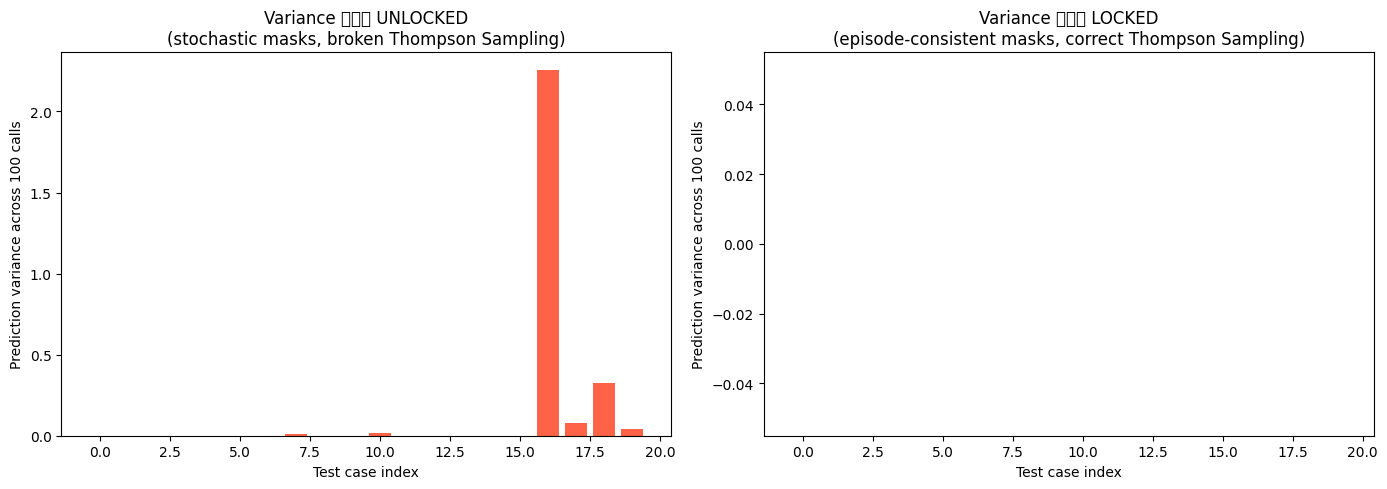


Summary table (unlocked vs locked):


,state,action,true,pred (unlocked),var (unlocked),pred (locked),var (locked)
0,0,0,5,5.0,0.0000,5.0,0.0
1,0,1,6,6.0,0.0000,6.0,0.0
2,5,0,10,10.0,0.0000,10.0,0.0
3,5,1,11,11.0,0.0000,11.0,0.0
4,6,0,10,10.0,0.0000,10.0,0.0
5,6,1,12,12.0,0.0000,12.0,0.0
6,10,0,15,15.0,0.0000,15.0,0.0
7,10,1,16,16.0,0.0099,16.0,0.0
8,11,0,15,15.0,0.0000,15.0,0.0
9,11,1,17,17.0,0.0000,17.0,0.0


In [126]:
# === Side-by-side variance comparison ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].bar(range(test_size), result_unlocked['variance'], color='tomato')
axes[0].set_title('Variance ﷿﷿﷿﷿﷿﷿﷿﷿﷿ UNLOCKED\n(stochastic masks, broken Thompson Sampling)')
axes[0].set_xlabel('Test case index')
axes[0].set_ylabel('Prediction variance across 100 calls')

axes[1].bar(range(test_size), result_locked['variance'], color='steelblue')
axes[1].set_title('Variance ﷿﷿﷿﷿﷿﷿﷿﷿﷿ LOCKED\n(episode-consistent masks, correct Thompson Sampling)')
axes[1].set_xlabel('Test case index')
axes[1].set_ylabel('Prediction variance across 100 calls')

plt.tight_layout()
plt.show()

print("\nSummary table (unlocked vs locked):")
comparison = pd.DataFrame({
    'state':          result_unlocked['current_state'].values,
    'action':         result_unlocked['action'].values,
    'true':           result_unlocked['true next_state'].values,
    'pred (unlocked)':result_unlocked['pred next_state'].values,
    'var  (unlocked)':result_unlocked['variance'].values,
    'pred (locked)':  result_locked['pred next_state'].values,
    'var  (locked)':  result_locked['variance'].values,
})
comparison